# Dars 22 — Uyga vazifa
**Hosila va gradient tushunchasi**


---


*Maqsad: bugungi darsni mustahkamlash — hosila, power rule, qisman hosila, gradient va gradient descent'ning birinchi qadami. Vazifalar osondan qiyinga qarab joylashgan; har bosqichni ketma-ket bajarilgan.*


---



## Mundarija1. Ta'rifni tushuntiring2. Power rule bilan hisoblash3. Ishorani o'qish4. Belgilarni moslash (Lagranj / Leybnits)5. Numerik hosila funksiyasi6. SymPy bilan hakamlik7. Qisman hosila8. Gradient vektori9. Minimumni topish10. Gradient descent siklini yozish11. Learning rate tajribasi12. Xatoni topish (debugging)

## 1-topshiriq. Ta'rifni tushuntiring
O'z so'zingiz bilan (2-3 gap) tushuntiring: hosila nima va u nima uchun limit orqali aniqlanadi? Spidometr (oniy tezlik) misolidan foydalaning.



**Javob: Hosila — bu funksiyaning ma'lum bir nuqtadagi o'zgarish tezligini ko'rsatadi. U limit orqali aniqlanadi, chunki oniy o'zgarish tezligini topish uchun vaqt oralig'ini deyarli 0 ga yaqinlashtirish kerak. Masalan, avtomobilning spidometri o'rtacha emas, aynan shu ondagi (oniy) tezlikni ko'rsatadi va hosila ham xuddi shunday ishlaydi.**

## 2-topshiriq. Power rule bilan hisoblang

Quyidagi funksiyalarning hosilasini QO'LDA toping (power rule + chiziqlilik qoidasi yordamida):

a) f(x) = x^5

b) f(x) = 4x^3

c) f(x) = 10 (o'zgarmas)

d) f(x) = 2x^2 - 3x + 7


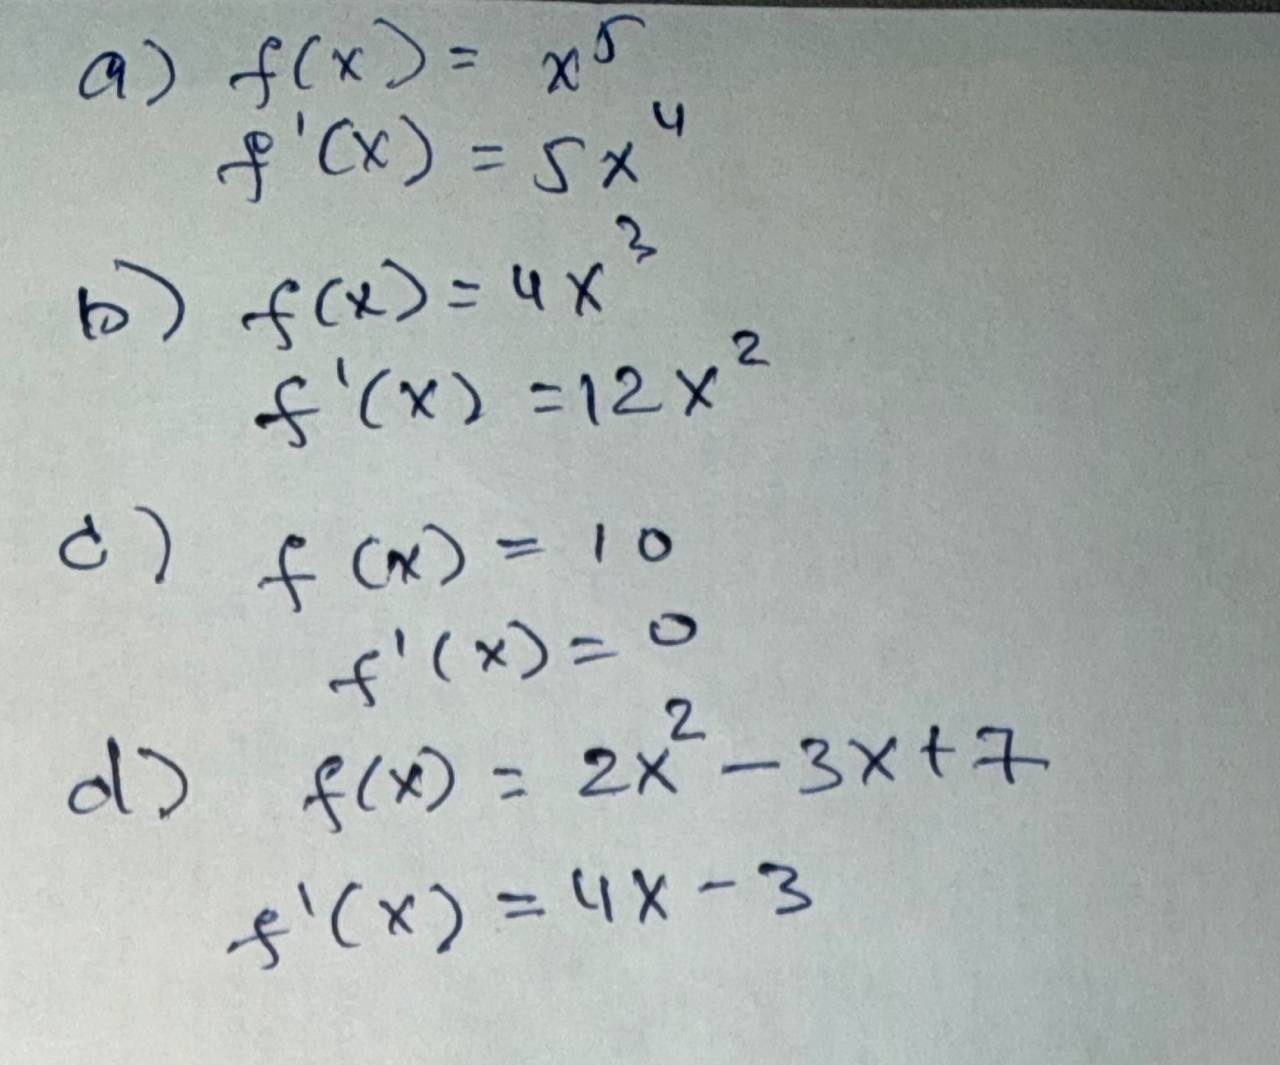


## 3-topshiriq. Ishorani o'qing

Har bir holat uchun funksiya o'sayaptimi, pasayaptimi yoki tekis nuqtadami — javob bering:

a) f'(2) = 5      ->  o'sayapti

b) f'(-1) = -3    ->  kamayyapti

c) f'(0) = 0      ->  tekis nuqta, to'xtagan



## 4-topshiriq. Belgilarni moslang
f'(x) va df/dx yozuvlari nimani anglatadi va ular bir xil narsami? Kimlarning nomi bilan atalgan (Lagranj / Leybnits)?

**Javob: `f′(x)` → Lagranj belgisi.
`df/dx` → Leybnits belgisi.
Ikkalasi ham hosilani bildiradi, faqat yozilish usuli va qo'llanishi biroz farq qiladi**

## 5-topshiriq. Numerik hosila funksiyasi
hosila(f, x, h=1e-5) funksiyasini yozing (darsdagi kabi) va quyidagi funksiyalar uchun x = -2, 0, 3 nuqtalarda hisoblang. Har bir natijani formula bilan tekshiring (qog'ozda hisoblab, mos kelishini yozing):

a) f(x) = x^2

b) f(x) = x^3 - 2x

c) f(x) = 1/x   (x=0 da nima bo'ladi? Nega?)



In [1]:
def hosila(f, x, h=1e-5):
  return (f(x+h) - f(x))/h

def fA(x): return x**2
def fB(x): return x**3-2*x
def fC(x): return x**(-1)

try:
  for x in [-2, 0, 3]:
    print('a) ', x, '->', hosila(fA, x))
    print('b) ', x, '->', hosila(fB, x))
    print('c) ', x, '->', hosila(fC, x))
    print()
except ZeroDivisionError:
  print("c) " ,x, "-> 0 ga bo'lish mumkin emas (funksiya bu nuqtada aniqlanmagan).")


a)  -2 -> -3.999990000025377
b)  -2 -> 9.999940000149365
c)  -2 -> -0.25000125001284346

a)  0 -> 1e-05
b)  0 -> -1.9999999999
c)  0 -> 0 ga bo'lish mumkin emas (funksiya bu nuqtada aniqlanmagan).


## 6-topshiriq. SymPy bilan hakamlik
sympy yordamida quyidagi funksiyalarning hosilasini toping va qo'lda topgan javobingiz bilan solishtiring:
```
import sympy as sp
x = sp.symbols('x')
a) f(x) = x**4 - 5*x
b) f(x) = 3/x         #(maslahat: x**-1 deb yozing)
c) f(x) = sp.sqrt(x)  # SymPy nima beradi?


```



In [2]:
import sympy as sp
x = sp.symbols('x')

print(f"a) {sp.diff(x**4 - 5*x)}")
print(f"b) {sp.diff(3*x**(-1))}")
print(f"c) {sp.diff(sp.sqrt(x))}")

a) 4*x**3 - 5
b) -3/x**2
c) 1/(2*sqrt(x))


## 7-topshiriq. Qisman hosila
f(x, y) = 3x^2 + 2xy - y^2 uchun ∂f/∂x va ∂f/∂y ni QO'LDA toping. Har birida qaysi o'zgaruvchi 'muzlatilganini' aniq yozing.


**Javob:**

df/dx = 6x + 2y (y muzlatilgan)

df/dy = 2x - 2y (x muzlatilgan)

## 8-topshiriq. Gradient vektori
7-topshiriqdagi funksiya uchun ∇f(1, 2) ni hisoblang. Natija VEKTOR ekanini unutmang — ikkita son [gx, gy] ko'rinishida yozing.


In [3]:
import numpy as np

def gradient(f, x, y, h=1e-5):
  gx = (f(x+h, y) - f(x, y))/h
  gy = (f(x, y+h) - f(x, y))/h
  return np.array([gx, gy])

def f(x, y): return (3*x**2+2*x*y-y**2)

print(gradient(f, 1, 2))

[10.00003 -2.00001]


## 9-topshiriq. Minimumni toping
f(x, y) = (x + 2)^2 + (y - 4)^2 berilgan.

a) df/dx va df/dy ni QO'LDA toping (qavsni ochish shart emas)

b) Gradient nol vektor bo'ladigan nuqtani toping.

c) numerik gradient(f, x, y) bilan (0, 0) va topilgan minimum
   nuqtada tekshiring. Ikkinchisida natija nolga yaqinmi?



**Javob:**

a) df/dx = 2(x+2); df/dy = 2(y-4)

b) 0 bo'ladigan nuqta: 2(x + 2) = 0 -> x = -2;
2(y - 4) = 0 -> y = 4

In [4]:
def gradient(f, x, y, h=1e-5):
    gx = (f(x + h, y) - f(x, y)) / h
    gy = (f(x, y + h) - f(x, y)) / h
    return np.array([gx, gy])

def f(x, y):
    return (x + 2)**2 + (y - 4)**2

print("Gradient at (0,0):")
print(gradient(f, 0, 0))

print("\nGradient at (-2,4):")
print(gradient(f, -2, 4))

Gradient at (0,0):
[ 4.00001 -7.99999]

Gradient at (-2,4):
[1.e-05 1.e-05]


c) Numerik gradient yordamida tekshirganda:

(0,0) nuqtada gradient nol emas, demak bu minimum emas.
(-2,4) nuqtada gradient juda kichik (0 ga juda yaqin) chiqadi. Bu numerik usul taqribiy hisoblagani uchun sodir bo'ladi va ushbu nuqta funksiyaning minimumi ekanligini tasdiqlaydi.

## 10-topshiriq. Gradient descent siklini yozing
`pastga_tush(f_hosila, x0, lr, qadamlar)` funksiyasini yozing (darsdagi 1D misol asosida, lekin o'zingiz qaytadan, qarab yozmasdan). Keyin `f(x) = (x - 5)^2` uchun x0 = -10, lr = 0.1, 25 qadam bilan ishga tushiring va har qadamdagi x qiymatini chop eting.


In [5]:
def f_hosila(x):
    return 2 * (x - 5)

def pastga_tush(f_hosila, x0, lr, qadamlar):
    x = x0

    for i in range(qadamlar):
        grad = f_hosila(x)
        x = x - lr * grad
        print(f"{i+1}-qadam: x = {x:.6f}")

    return x

natija = pastga_tush(f_hosila=f_hosila, x0=-10, lr=0.1, qadamlar=25)
print(f"\nOxirgi qiymat: {natija:.6f}")

1-qadam: x = -7.000000
2-qadam: x = -4.600000
3-qadam: x = -2.680000
4-qadam: x = -1.144000
5-qadam: x = 0.084800
6-qadam: x = 1.067840
7-qadam: x = 1.854272
8-qadam: x = 2.483418
9-qadam: x = 2.986734
10-qadam: x = 3.389387
11-qadam: x = 3.711510
12-qadam: x = 3.969208
13-qadam: x = 4.175366
14-qadam: x = 4.340293
15-qadam: x = 4.472234
16-qadam: x = 4.577788
17-qadam: x = 4.662230
18-qadam: x = 4.729784
19-qadam: x = 4.783827
20-qadam: x = 4.827062
21-qadam: x = 4.861649
22-qadam: x = 4.889320
23-qadam: x = 4.911456
24-qadam: x = 4.929165
25-qadam: x = 4.943332

Oxirgi qiymat: 4.943332


## 11-topshiriq. Learning rate tajribasi
10-topshiriqdagi funksiya uchun lr ni 0.01, 0.3 va 1.2 qilib uch marta ishga tushiring. Har biri uchun: (a) 25 qadamdan keyin qayerga keldi, (b) nega shunday bo'ldi — o'z so'zingiz bilan 2-3 gapda tushuntiring.


In [6]:
def f_hosila(x):
    return 2 * (x - 5)

def pastga_tush(f_hosila, x0, lr, qadamlar):
    x = x0

    for i in range(qadamlar):
        grad = f_hosila(x)
        x = x - lr * grad
        print(f"{i+1}-qadam: x = {x:.6f}")

    return x

natija = pastga_tush(f_hosila, x0=-10, lr=0.01, qadamlar=25)
print(f"\nOxirgi qiymat: {natija:.6f}")

1-qadam: x = -9.700000
2-qadam: x = -9.406000
3-qadam: x = -9.117880
4-qadam: x = -8.835522
5-qadam: x = -8.558812
6-qadam: x = -8.287636
7-qadam: x = -8.021883
8-qadam: x = -7.761445
9-qadam: x = -7.506216
10-qadam: x = -7.256092
11-qadam: x = -7.010970
12-qadam: x = -6.770751
13-qadam: x = -6.535336
14-qadam: x = -6.304629
15-qadam: x = -6.078537
16-qadam: x = -5.856966
17-qadam: x = -5.639826
18-qadam: x = -5.427030
19-qadam: x = -5.218489
20-qadam: x = -5.014120
21-qadam: x = -4.813837
22-qadam: x = -4.617560
23-qadam: x = -4.425209
24-qadam: x = -4.236705
25-qadam: x = -4.051971

Oxirgi qiymat: -4.051971


a) Natija 25 qadamdan keyin: `x≈−4.046`

Minimumga hali yetib bormaydi.

b) `lr = 0.01 `juda kichik bo'lgani uchun model har safar juda kichik qadam tashlaydi. Shuning uchun minimum tomon harakat qiladi, lekin 25 qadam ichida 5 ga yetib bora olmaydi. Agar qadamlar sonini oshirsak, oxir-oqibat minimumga yaqinlashadi.

In [7]:
natija = pastga_tush(f_hosila, x0=-10, lr=0.3, qadamlar=25)
print(f"\nOxirgi qiymat: {natija:.6f}")

1-qadam: x = -1.000000
2-qadam: x = 2.600000
3-qadam: x = 4.040000
4-qadam: x = 4.616000
5-qadam: x = 4.846400
6-qadam: x = 4.938560
7-qadam: x = 4.975424
8-qadam: x = 4.990170
9-qadam: x = 4.996068
10-qadam: x = 4.998427
11-qadam: x = 4.999371
12-qadam: x = 4.999748
13-qadam: x = 4.999899
14-qadam: x = 4.999960
15-qadam: x = 4.999984
16-qadam: x = 4.999994
17-qadam: x = 4.999997
18-qadam: x = 4.999999
19-qadam: x = 5.000000
20-qadam: x = 5.000000
21-qadam: x = 5.000000
22-qadam: x = 5.000000
23-qadam: x = 5.000000
24-qadam: x = 5.000000
25-qadam: x = 5.000000

Oxirgi qiymat: 5.000000


a) Natija 25 qadamdan keyin: `x≈5.000`

(5 ga juda yaqin qiymat chiqadi.)

b) `lr = 0.3` yaxshi tanlangan learning rate hisoblanadi. Model yetarlicha katta qadamlar bilan harakat qiladi, lekin minimumdan oshib ketmaydi. Natijada 25 qadam ichida minimumga juda yaqinlashadi.

In [8]:
natija = pastga_tush(f_hosila, x0=-10, lr=1.2, qadamlar=25)
print(f"\nOxirgi qiymat: {natija:.6f}")

1-qadam: x = 26.000000
2-qadam: x = -24.400000
3-qadam: x = 46.160000
4-qadam: x = -52.624000
5-qadam: x = 85.673600
6-qadam: x = -107.943040
7-qadam: x = 163.120256
8-qadam: x = -216.368358
9-qadam: x = 314.915702
10-qadam: x = -428.881982
11-qadam: x = 612.434775
12-qadam: x = -845.408686
13-qadam: x = 1195.572160
14-qadam: x = -1661.801024
15-qadam: x = 2338.521433
16-qadam: x = -3261.930007
17-qadam: x = 4578.702009
18-qadam: x = -6398.182813
19-qadam: x = 8969.455938
20-qadam: x = -12545.238314
21-qadam: x = 17575.333639
22-qadam: x = -24593.467095
23-qadam: x = 34442.853933
24-qadam: x = -48207.995506
25-qadam: x = 67503.193709

Oxirgi qiymat: 67503.193709


a) Natija qiymatlari juda kattalashib ketadi. Har safar minimumning bir tomonidan ikkinchi tomoniga sakraydi va asta-sekin uzoqlashadi.

25-qadamda qiymat juda katta bo'lib ketadi.

b) `lr = 1.2` juda katta bo'lgani uchun model har safar minimumdan oshib ketadi. Natijada u minimum atrofida to'xtamaydi, balki bir tomondan ikkinchi tomonga sakrab yuradi va xatolik ortib boradi. Bunday learning rate bilan Gradient Descent barqaror ishlamaydi.

## 12-topshiriq. Xatoni toping (debugging)
Quyidagi kod noto'g'ri ishlaydi — minimumga tushish o'rniga uzoqlashadi. Xatoni toping, sababini yozing va to'g'rilangan kodni keltiring:


```
def gd_xato(f_hosila, x0, lr, qadamlar):
    x = x0
    for i in range(qadamlar):
        grad = f_hosila(x)
        x = x + lr * grad   # <-- shu yerda muammo bor
    return x
```



Bu Gradient Descent emas, balki Gradient Ascent bo'ladi. Natijada algoritm minimumga yaqinlashmaydi, aksincha undan uzoqlashadi. To'g'ri formula:

`x = x - lr * grad`

bo'lishi kerak, chunki Gradient Descent har doim gradientning teskari yo'nalishida harakat qiladi.